In [2]:
import pandas as pd
import numpy as np

In [2]:
articles = pd.read_csv(r"C:\Users\Parsa\Downloads\articles.csv")

In [3]:
final_articles = pd.read_csv(r"C:\Users\Parsa\Downloads\final_articles (1).csv")

In [4]:
profs = pd.read_csv(r"C:\Users\Parsa\Downloads\professors.csv")

# Removing Duplicates

In [4]:
articles = articles.drop_duplicates('GS_link', keep='last')

In [5]:
articles['GS_link'].duplicated().sum()

0

In [6]:
final_articles = final_articles.drop_duplicates('GS_link', keep='last')

In [7]:
final_articles['GS_link'].duplicated().sum()

0

In [9]:
articles.to_csv('../articles.csv', index=False)

In [10]:
final_articles.to_csv("../final_articles.csv", index=False)

In [7]:
uni = pd.read_csv(r"C:\Users\Parsa\Downloads\universities.csv")

In [3]:
final_articles

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
0,70,Timing of surgery following SARS‐CoV‐2 infecti...,COVIDSurg Collaborative,2021/6,Anaesthesia,76.0,6,748-758,Wiley-Blackwell Publishing Ltd.,588,Peri-operative SARS-CoV-2 infection increases ...,/citations?view_op=view_citation&hl=en&user=_C...,https://pure.au.dk/portal/en/publications/timi...,https://pure.au.dk/portal/files/273706648/Anae...,[{'title': 'Timing of surgery following SARS-C...,"[{'year': '2020', 'count': '2'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
1,284,SARS-CoV-2 infection and venous thromboembolis...,"Collaborative COVIDSurg, Collaborative GlobalSurg",2022,Anaesthesia,77.0,1,28-39,Association of Anaesthetists,109,SARS-CoV-2 has been associated with an increas...,/citations?view_op=view_citation&hl=en&user=_C...,https://boris.unibe.ch/162951/,https://boris.unibe.ch/162951/1/Anaesthesia_-_...,[{'title': 'SARS-CoV-2 infection and venous th...,"[{'year': '2021', 'count': '4'}, {'year': '202...",0-116,Life Sciences & Biomedicine
2,319,Effects of pre‐operative isolation on postoper...,"COVIDSurg Collaborative, GlobalSurg Collaborat...",2021/11,Anaesthesia,76.0,11,1454-1464,NaN,45,We aimed to determine the impact of pre‐operat...,/citations?view_op=view_citation&hl=en&user=_C...,https://associationofanaesthetists-publication...,https://associationofanaesthetists-publication...,[{'title': 'Effects of pre‐operative isolation...,"[{'year': '2021', 'count': '5'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
3,395,Parameter identification of complex network dy...,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2021/6,Nonlinear Dynamics,104.0,4,3991-4005,Springer Netherlands,4,"Here, we present a novel approach called the “...",/citations?view_op=view_citation&hl=en&user=_C...,https://link.springer.com/article/10.1007/s110...,NaN,[{'title': 'Parameter identification of comple...,"[{'year': '2023', 'count': '3'}, {'year': '202...",0-763,Information and Computing Sciences
4,396,Data-Driven Discovery of Social Network Dynamics,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2020/9/16,NaN,NaN,NaN,39-45,IEEE,2,"In recent years, rigorous mathematical framewo...",/citations?view_op=view_citation&hl=en&user=_C...,https://ieeexplore.ieee.org/abstract/document/...,NaN,[{'title': 'Data-driven discovery of social ne...,"[{'year': '2023', 'count': '2'}]",0-763,Information and Computing Sciences
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177333,1484225,طراحی یکپارچه سایبان‌های پوسته جنوبی ساختمان خ...,"رزمی, افشین, ترکاشوند, رهبر, اخلاصی, احمد",2022/5/10,نشریه هنرهای زیبا: معماری و شهرسازی,27.0,1,63-74,دانشگاه تهران دانشکدگان هنرهای زیبا,0,یافتن متوازن‌ترین گزینه طراحی ضمن در نظر گرفتن...,https://scholar.google.com/citations?view_op=v...,https://jfaup.ut.ac.ir/article_88579.html?lang=fa,https://jfaup.ut.ac.ir/article_88579_8a71464d9...,[{'title': 'طراحی یکپارچه سایبان\u200cهای پوست...,[],50912,Built Environment and Design
177334,1484226,A fuzzy‐based method for cloud service migrati...,"Zhiqiang Liu, Bo Xu, Bo Cheng, Xiaomei Hu, Kar...",2022/4/12,Concurrency and Computation: Practice and Expe...,NaN,NaN,e6970,"John Wiley & Sons, Inc.",1,Computation should develop and become more pow...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,NaN,[{'title': 'A fuzzy‐based method for cloud ser...,"[{'year': '2023', 'count': '1'}]",50912,Information and Computing Sciences
177335,1484227,A new approach for service migration in cloud‐...,"Lixia Huang, Karlo Abnoosian",2020/6/2,International Journal of Communication Systems,33.0,14,e4457,NaN,7,Service‐oriented architecture (SOA) has a cruc...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,https://www.academia.edu/download/96654671/dac...,[{'title':

In [4]:
# 1. Take your column, drop any NaNs, split on '-' and explode into one ID per row
ids_exploded = (
    final_articles['link_ids']
    .dropna()
    .astype(str)               # ensure everything is a string
    .str.split('-')           # ['19','166','15'], ['15'], ...
    .explode()                # one row per ID
)

# 2. (Optional) convert to int if you know they’re all ints
ids_exploded = ids_exploded.astype(int)

# 3. Count how many distinct IDs there are
n_unique = ids_exploded.nunique()

print(f"Total unique professor IDs: {n_unique}")


Total unique professor IDs: 17459


In [8]:
# If you haven’t already, get your array of unique prof IDs:
unique_ids = ids_exploded.astype(int).unique()

# Now filter your profs DataFrame for just those IDs.
# Replace 'id' below with whatever column holds the professor ID in profs.
selected_profs = profs[profs['id'].isin(unique_ids)]

# Pull out the university column, drop any NaNs, and get the uniques
unique_universities = selected_profs['university'].dropna().unique()

# How many distinct universities?
print(f"Found {len(unique_universities)} unique universities:")
print(unique_universities)


Found 78 unique universities:
['University of Tehran' 'Sharif University of Technology'
 'Tehran University of Medical Sciences'
 'Shahid Beheshti University of Medical Sciences'
 'Ferdowsi University of Mashhad' 'Amirkabir University of Technology'
 'Shahid Beheshti University' 'Mashhad University of Medical Sciences'
 'University of Isfahan' 'Tarbiat Modares University' 'Shiraz University'
 'Isfahan University of Technology' 'University of Tabriz'
 'Shiraz University of Medical Sciences'
 'Isfahan University of Medical Sciences'
 'Tabriz University of Medical Sciences'
 'Iran University of Science and Technology' 'Urmia University'
 'Shahid Chamran University of Ahvaz' 'Zanjan University'
 "Allameh Tabataba'i University" 'Alzahra University'
 'The University of Guilan' 'Semnan University' 'Shahrekord University'
 'Institute for Research in Fundamental Sciences'
 'University of Social Welfare and Rehabilitation Sciences'
 'Yazd University' 'University of Kashan'
 'Hamadan University o

In [4]:
articles

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
0,0,Observation of a new boson at a mass of 125 Ge...,/citations?view_op=view_citation&hl=en&user=_C...,2012.0,22285,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Physics Letters B 716 (1)- 30-61- 2012,0-5600-21725-21726-33843-34234
1,1,Observation of a new boson with mass near 125 ...,/citations?view_op=view_citation&hl=en&user=_C...,2013.0,6018,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2013 (6)- 1-127...,0-0-5600-21725-21726-21726-21726-21726-21726-2...
2,2,Precise determination of the mass of the Higgs...,/citations?view_op=view_citation&hl=en&user=_C...,2015.0,4801,CMS Collaboration,Eur. Phys. J. C 75 (5)- 212- 2015,0-5600-21725-33843-34234
3,3,Evidence for the 125 GeV Higgs boson decaying ...,/citations?view_op=view_citation&hl=en&user=_C...,2014.0,4605,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2014 (5)- 1-72-...,0-0-5600-21725-33843-34234
4,4,Event generator tunes obtained from underlying...,/citations?view_op=view_citation&hl=en&user=_C...,2016.0,4536,V Khachatryan- AM Sirunyan- A Tumasyan- W Adam...,The European Physical Journal C 76- 1-52- 2016,0-5600-21725-21726-33843-34234
...,...,...,...,...,...,...,...,...
1445692,1484281,Design of a Frequency up-converted Electromagn...,https://scholar.google.com/citations?view_op=v...,2023.0,0,"M Asadi, R Ahmadi, AM Abazari","8th Annual Clean Energy, 2023",50957
1445693,1484282,Frequency analysis of a two-degree-of-freedom ...,https://scholar.google.com/citations?view_op=v...,2023.0,0,"M Asadi, R Ahmadi, M Farajollahi, AM Abazari",6th National Conference on Application of Nove...,50957
1445694,1484283,"<span dir=""rtl"">تحلیل یک سیستم کمکی گرمایش از ...",https://scholar.google.com/citations?view_op=v...,2022.0,0,"اسدی, اباذری, امیرموسی, حسنوند, امین‎","نشریه مهندسی مکانیک امیرکبیر 54 (5), 1081-1100...",50957
1445695,1484285,A conical beam finite element formulation for ...,https://scholar.google.com/citations?view_op=v...,2023.0,0,"A Ajdani, P Shahabi, A Ghaheri","Iranian Society of Mechanical Engineers 31, 2023",50962


In [5]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445697 entries, 0 to 1445696
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   id            1445697 non-null  int64  
 1   title         1445697 non-null  object 
 2   GS_link       1445697 non-null  object 
 3   year          1356127 non-null  float64
 4   cite          1445697 non-null  int64  
 5   main_authors  1445697 non-null  object 
 6   more_info     1345175 non-null  object 
 7   link_ids      1445697 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 88.2+ MB


In [6]:
articles.describe(include="all")

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
count,1.445697e+06,1445697,1445697,1.356127e+06,1.445697e+06,1445697,1345175,1445697
unique,NaN,1403860,1445685,NaN,NaN,1190442,1186404,261433
top,NaN,The 16th Iranian Chemistry Congress,/citations?view_op=view_citation&hl=en&user=tq...,NaN,NaN,S Arfania- AR Sayadi- MR Khalesi,Journal of the Southern African Institute of M...,45716
freq,NaN,143,2,NaN,NaN,1579,1581,2444
mean,7.370980e+05,NaN,NaN,2.011774e+03,1.107105e+01,NaN,NaN,NaN
std,4.267519e+05,NaN,NaN,4.603951e+01,9.497828e+01,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,1.000000e+00,0.000000e+00,NaN,NaN,NaN
25%,3.675010e+05,NaN,NaN,2.012000e+03,0.000000e+00,NaN,NaN,NaN
50%,7.358590e+05,NaN,NaN,2.016000e+03,1.000000e+00,NaN,NaN,NaN
75%,1.106546e+06,NaN,NaN,2.019000e+03,9.000000e+00,NaN,NaN,NaN


In [7]:
articles.isna().sum().sort_values(ascending=False)

more_info       100522
year             89570
id                   0
title                0
GS_link              0
cite                 0
main_authors         0
link_ids             0
dtype: int64

In [16]:
articles[articles["id"] == 919490]

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
901840,919490,تحلیل عملکرد و بهینه سازی محفظه احتراق میکروتو...,/citations?view_op=view_citation&hl=en&user=9g...,2015.0,0,صدیقی- اغنیا- احمدخواه- انور- نیسی‎,نشریه علمی-پژوهشی مهندسی هوانوردی 16 (2)- 47-6...,30288


In [35]:
articles['GS_link'].duplicated().sum()

12

In [37]:
articles['GS_link'].duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1445692    False
1445693    False
1445694    False
1445695    False
1445696    False
Name: GS_link, Length: 1445697, dtype: bool

In [38]:
pd.concat(g for _, g in articles.groupby("GS_link") if len(g) > 1)

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
1281222,1308761,Relationship of vegetation and geomorphic indi...,/citations?view_op=view_citation&hl=en&user=2b...,2022,0,M Abedini- S Javadi- R Mostafazadeh- AH Pasban,Hydrogeomorphology 9 (32)- 128-105- 2022,43931-43999
1281502,1309049,Relationship of vegetation and geomorphic indi...,/citations?view_op=view_citation&hl=en&user=2b...,2022,0,M Abedini- SJA Babalu- R Mostafazadeh- AH Pasban,Hydrogeomorphology 9 (32)- 128-105- 2022,43931-43999-44640
1278865,1306359,The relationship between academic optimism and...,/citations?view_op=view_citation&hl=en&user=2u...,2020,6,A Zahed Babelan- G Karimianpour,Educational and Scholastic studies 9 (1)- 149-...,43895
1278971,1306466,The Relationship between Academic Optimism and...,/citations?view_op=view_citation&hl=en&user=2u...,2020,6,A Zahed Babelan- G Karimianpour,Educational and Scholastic studies 9 (1)- 149-...,43895
1270823,1298105,Geometric properties of normalized imaginary e...,/citations?view_op=view_citation&hl=en&user=E9...,2022,0,NH Mohammed- NE Cho- EA Adegani- T Bulboacă,Studia Universitatis Babes-Bolyai- Mathematica...,43600
1270830,1298113,Geometric properties of normalized imaginary e...,/citations?view_op=view_citation&hl=en&user=E9...,2022,0,NH Mohammed- NE Cho- EA Adegani- T Bulboaca,Studia Universitatis Babes-Bolyai- Mathematica...,43600
1242711,1269194,Virtual Grand Rounds in Medical Education Duri...,/citations?view_op=view_citation&hl=en&user=Gz...,2022,0,ZIP Mobarakeh- HY Nejad- M Amiri- F Taheri,Acta Medica Iranica 60 (8)- 437- 2022,42367
1242716,1269199,Virtual Grand Rounds in Medical Education Duri...,/citations?view_op=view_citation&hl=en&user=Gz...,2022,0,ZI Pour Mobarakeh- HY Nejad- M Amiri- F Taheri,Acta Medica Iranica 60 (8)- 2022,42367
1231723,1257855,The Relationship between Managers Communicatio...,/citations?view_op=view_citation&hl=en&user=Mc...,2022,0,M Amraei- H Valizadi- MH Haghighizadeh- F Fara...,Depiction of Health 13 (1)- 83-96- 2022,41937
1231781,1257913,The Relationship between Managers Communicatio...,/citations?view_op=view_citation&hl=en&user=Mc...,2022,0,M Amraei- H Valizadi- M Hosein Haghighizadeh,Depiction of Health- 2022,41937-42571


In [9]:
pd.concat(g for _, g in final_articles.groupby("GS_link") if len(g) > 1)

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
153303,1306359,The relationship between academic optimism and...,"Adel Zahed Babelan, Ghaffar Karimianpour",2020/3/20,Educational and Scholastic studies,9.0,1,149-170,Farhangian University,9,"Following a descriptive-correlational design, ...",/citations?view_op=view_citation&hl=en&user=2u...,https://pma.cfu.ac.ir/article_1210.html?lang=en,NaN,[{'title': 'The relationship between academic ...,"[{'year': '2020', 'count': '1'}, {'year': '202...",43895,Education
153323,1306466,The Relationship between Academic Optimism and...,"Adel Zahed Babelan, Ghaffar Karimianpour",2020/3/20,Educational and Scholastic studies,9.0,1,149-170,Farhangian University,9,"Following a descriptive-correlational design, ...",/citations?view_op=view_citation&hl=en&user=2u...,https://pma.cfu.ac.ir/article_1210.html?lang=en,NaN,[{'title': 'The relationship between academic ...,"[{'year': '2020', 'count': '1'}, {'year': '202...",43895,Education
151407,1298105,Geometric properties of normalized imaginary e...,"N Hameed Mohammed, Nak Eun Cho, Ebrahim Analou...",2022/6/1,Studia Universitatis Babes-Bolyai Matematica,67.0,2,455-462,NaN,15,The error function takes place in a wide range...,/citations?view_op=view_citation&hl=en&user=E9...,https://www.academia.edu/download/92197327/138...,https://www.academia.edu/download/92197327/138...,[{'title': 'Geometric properties of normalized...,"[{'year': '2023', 'count': '3'}, {'year': '202...",43600,Mathematical Sciences
151411,1298113,Geometric properties of normalized imaginary e...,"N Hameed Mohammed, Nak Eun Cho, Ebrahim Analou...",2022/6/1,Studia Universitatis Babes-Bolyai Matematica,67.0,2,455-462,NaN,15,The error function takes place in a wide range...,/citations?view_op=view_citation&hl=en&user=E9...,https://www.academia.edu/download/92197327/138...,https://www.academia.edu/download/92197327/138...,[{'title': 'Geometric properties of normalized...,"[{'year': '2023', 'count': '3'}, {'year': '202...",43600,Mathematical Sciences
155219,1315466,استخراج نقشه کاربری کاربری اراضی شهرستان سوسنگ...,"اصغری سراسکانرود, صیاد, ناصری, احمد",2020/5/10,فضای جغرافیایی,20.0,69,77-95,فضای جغرافیایی,0,بر اثر فعالیتهای انسانی و پدیدههای طبیعی، چهره...,/citations?view_op=view_citation&hl=en&user=OL...,http://geographical-space.iau-ahar.ac.ir/artic...,http://geographical-space.iau-ahar.ac.ir/files...,[{'title': 'استخراج نقشه کاربری کاربری اراضی ش...,[],44065,Earth Sciences
155231,1315676,استخراج نقشه کاربری کاربری اراضی شهرستان سوسنگ...,"اصغری سراسکانرود, صیاد, ناصری, احمد",2020/5/10,فضای جغرافیایی,20.0,69,77-95,فضای جغرافیایی,0,بر اثر فعالیتهای انسانی و پدیدههای طبیعی، چهره...,/citations?view_op=view_citation&hl=en&user=OL...,http://geographical-space.iau-ahar.ac.ir/artic...,http://geographical-space.iau-ahar.ac.ir/files...,[{'title': 'استخراج نقشه کاربری کاربری اراضی ش...,[],44065,Earth Sciences


In [36]:
articles['id'].duplicated().sum()

0

In [5]:
pd.concat(g for _, g in profs.groupby("id") if len(g) > 1)

ValueError: No objects to concatenate

In [6]:
profs['id'].duplicated().sum()

0

In [9]:
uni['org_id'].duplicated().sum()

215

In [21]:
import pandas as pd
from datetime import datetime

def shamsi_to_gregorian_year(y):
    """
    If y is an integer between 1300 and 1500 (likely a Jalali year),
    convert to Gregorian by adding 621.
    Otherwise return y cast to int (or pd.NA if invalid).
    """
    today = datetime.today() # to get current date
    try:
        yi = int(y)
    except (TypeError, ValueError):
        return pd.NA
    if 1300 <= yi <= (today.year - 621):# getting the shamsi year by subtracting 621
        return yi + 621
    return yi

def convert_publication_years(df, year_col='publication_year'):
    """
    Apply shamsi_to_gregorian_year to every entry in df[year_col].
    Returns a new Series of cleaned years.
    """
    return df[year_col].apply(shamsi_to_gregorian_year)

# ----------- Example Usage -----------
# df = pd.read_csv('articles.csv')
# df['publication_year'] = convert_publication_years(df, 'publication_year')
# df.to_csv('articles_converted.csv', index=False)


In [22]:
articles['year'] = convert_publication_years(articles, 'year')

In [23]:
articles

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
0,0,Observation of a new boson at a mass of 125 Ge...,/citations?view_op=view_citation&hl=en&user=_C...,2012,22285,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Physics Letters B 716 (1)- 30-61- 2012,0-5600-21725-21726-33843-34234
1,1,Observation of a new boson with mass near 125 ...,/citations?view_op=view_citation&hl=en&user=_C...,2013,6018,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2013 (6)- 1-127...,0-0-5600-21725-21726-21726-21726-21726-21726-2...
2,2,Precise determination of the mass of the Higgs...,/citations?view_op=view_citation&hl=en&user=_C...,2015,4801,CMS Collaboration,Eur. Phys. J. C 75 (5)- 212- 2015,0-5600-21725-33843-34234
3,3,Evidence for the 125 GeV Higgs boson decaying ...,/citations?view_op=view_citation&hl=en&user=_C...,2014,4605,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2014 (5)- 1-72-...,0-0-5600-21725-33843-34234
4,4,Event generator tunes obtained from underlying...,/citations?view_op=view_citation&hl=en&user=_C...,2016,4536,V Khachatryan- AM Sirunyan- A Tumasyan- W Adam...,The European Physical Journal C 76- 1-52- 2016,0-5600-21725-21726-33843-34234
...,...,...,...,...,...,...,...,...
1445692,1484281,Design of a Frequency up-converted Electromagn...,https://scholar.google.com/citations?view_op=v...,2023,0,"M Asadi, R Ahmadi, AM Abazari","8th Annual Clean Energy, 2023",50957
1445693,1484282,Frequency analysis of a two-degree-of-freedom ...,https://scholar.google.com/citations?view_op=v...,2023,0,"M Asadi, R Ahmadi, M Farajollahi, AM Abazari",6th National Conference on Application of Nove...,50957
1445694,1484283,"<span dir=""rtl"">تحلیل یک سیستم کمکی گرمایش از ...",https://scholar.google.com/citations?view_op=v...,2022,0,"اسدی, اباذری, امیرموسی, حسنوند, امین‎","نشریه مهندسی مکانیک امیرکبیر 54 (5), 1081-1100...",50957
1445695,1484285,A conical beam finite element formulation for ...,https://scholar.google.com/citations?view_op=v...,2023,0,"A Ajdani, P Shahabi, A Ghaheri","Iranian Society of Mechanical Engineers 31, 2023",50962


In [24]:
articles[articles["id"] == 968872]

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
949913,968872,تاریخ تحولات هنر گرافیک در جهان‎,/citations?view_op=view_citation&hl=en&user=f2...,1981,0,روئین پاکباز، فهیمه دانشگر، برزو ایزدپناه‎,NaN,31728


In [25]:
articles

,id,title,GS_link,year,cite,main_authors,more_info,link_ids
0,0,Observation of a new boson at a mass of 125 Ge...,/citations?view_op=view_citation&hl=en&user=_C...,2012,22285,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Physics Letters B 716 (1)- 30-61- 2012,0-5600-21725-21726-33843-34234
1,1,Observation of a new boson with mass near 125 ...,/citations?view_op=view_citation&hl=en&user=_C...,2013,6018,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2013 (6)- 1-127...,0-0-5600-21725-21726-21726-21726-21726-21726-2...
2,2,Precise determination of the mass of the Higgs...,/citations?view_op=view_citation&hl=en&user=_C...,2015,4801,CMS Collaboration,Eur. Phys. J. C 75 (5)- 212- 2015,0-5600-21725-33843-34234
3,3,Evidence for the 125 GeV Higgs boson decaying ...,/citations?view_op=view_citation&hl=en&user=_C...,2014,4605,S Chatrchyan- V Khachatryan- AM Sirunyan- A Tu...,Journal of High Energy Physics 2014 (5)- 1-72-...,0-0-5600-21725-33843-34234
4,4,Event generator tunes obtained from underlying...,/citations?view_op=view_citation&hl=en&user=_C...,2016,4536,V Khachatryan- AM Sirunyan- A Tumasyan- W Adam...,The European Physical Journal C 76- 1-52- 2016,0-5600-21725-21726-33843-34234
...,...,...,...,...,...,...,...,...
1445692,1484281,Design of a Frequency up-converted Electromagn...,https://scholar.google.com/citations?view_op=v...,2023,0,"M Asadi, R Ahmadi, AM Abazari","8th Annual Clean Energy, 2023",50957
1445693,1484282,Frequency analysis of a two-degree-of-freedom ...,https://scholar.google.com/citations?view_op=v...,2023,0,"M Asadi, R Ahmadi, M Farajollahi, AM Abazari",6th National Conference on Application of Nove...,50957
1445694,1484283,"<span dir=""rtl"">تحلیل یک سیستم کمکی گرمایش از ...",https://scholar.google.com/citations?view_op=v...,2022,0,"اسدی, اباذری, امیرموسی, حسنوند, امین‎","نشریه مهندسی مکانیک امیرکبیر 54 (5), 1081-1100...",50957
1445695,1484285,A conical beam finite element formulation for ...,https://scholar.google.com/citations?view_op=v...,2023,0,"A Ajdani, P Shahabi, A Ghaheri","Iranian Society of Mechanical Engineers 31, 2023",50962


In [27]:
from datetime import datetime
today = datetime.today()
#datem = datetime(today.year, today.month, 1)

In [28]:
today

datetime.datetime(2025, 8, 1, 6, 57, 17, 242010)

In [33]:
today.year -621

1404

datetime.datetime

In [41]:
articles[articles['id'] == 394310]['title']

387801    -metric spaceshello
Name: title, dtype: object

In [ ]:
# 1) Googletrans-based transliteration
#    pip install googletrans==4.0.0-rc1

from googletrans import Translator

_translator = Translator()

def transliterate_via_google(text: str) -> str:
    """
    Uses Google Translate API (via googletrans) to get the 'pronunciation'
    field of a Farsi (fa) → English transliteration.
    Falls back to the translated text if no pronunciation is returned.
    """
    if not isinstance(text, str) or not text.strip():
        return text
    try:
        res = _translator.translate(text, src='fa', dest='en')
        # pronunciation is the romanized original; text is the actual translation
        return res.pronunciation or res.text
    except Exception:
        # in case of rate limits or network issues, just return original
        return text

def apply_finglish_with_google(df, col: str, new_col: str = None):
    """
    Applies transliterate_via_google to df[col], writing results into new_col.
    If new_col is None, overwrites df[col].
    """
    out = new_col or col
    df[out] = df[col].fillna('').map(transliterate_via_google)
    return df


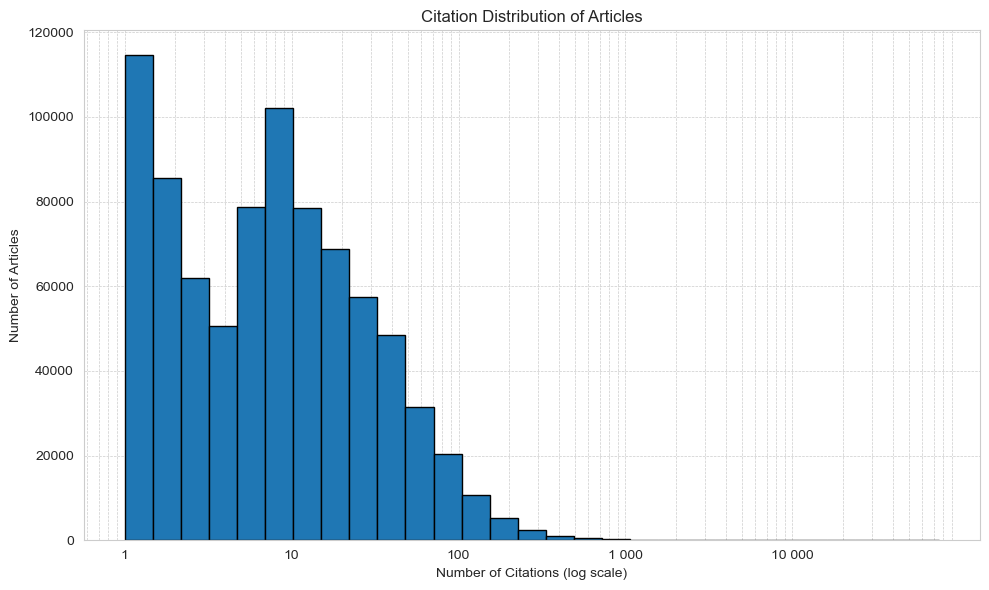

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Pull out the citation counts and coerce to numeric
citations = pd.to_numeric(articles['cite'], errors='coerce').dropna()

# 2. Build log-spaced bins (you can adjust num=30 up or down)
bins = np.logspace(np.log10(1), np.log10(citations.max() + 1), num=30)

# 3. Plot
plt.figure(figsize=(10, 6))
plt.hist(citations, bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Number of Citations (log scale)')
plt.ylabel('Number of Articles')
plt.title('Citation Distribution of Articles')
plt.xticks([1, 10, 100, 1000, 10000],
           ['1', '10', '100', '1 000', '10 000'])
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Picking sample for experts

In [3]:
final_articles = pd.read_csv(r"C:\Users\Parsa\Downloads\Aug 6 mml Files\final_articles.csv")

In [3]:
final_articles

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
0,70,Timing of surgery following SARS‐CoV‐2 infecti...,COVIDSurg Collaborative,2021/6,Anaesthesia,76.0,6,748-758,Wiley-Blackwell Publishing Ltd.,588,Peri-operative SARS-CoV-2 infection increases ...,/citations?view_op=view_citation&hl=en&user=_C...,https://pure.au.dk/portal/en/publications/timi...,https://pure.au.dk/portal/files/273706648/Anae...,[{'title': 'Timing of surgery following SARS-C...,"[{'year': '2020', 'count': '2'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
1,284,SARS-CoV-2 infection and venous thromboembolis...,"Collaborative COVIDSurg, Collaborative GlobalSurg",2022,Anaesthesia,77.0,1,28-39,Association of Anaesthetists,109,SARS-CoV-2 has been associated with an increas...,/citations?view_op=view_citation&hl=en&user=_C...,https://boris.unibe.ch/162951/,https://boris.unibe.ch/162951/1/Anaesthesia_-_...,[{'title': 'SARS-CoV-2 infection and venous th...,"[{'year': '2021', 'count': '4'}, {'year': '202...",0-116,Life Sciences & Biomedicine
2,319,Effects of pre‐operative isolation on postoper...,"COVIDSurg Collaborative, GlobalSurg Collaborat...",2021/11,Anaesthesia,76.0,11,1454-1464,NaN,45,We aimed to determine the impact of pre‐operat...,/citations?view_op=view_citation&hl=en&user=_C...,https://associationofanaesthetists-publication...,https://associationofanaesthetists-publication...,[{'title': 'Effects of pre‐operative isolation...,"[{'year': '2021', 'count': '5'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
3,395,Parameter identification of complex network dy...,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2021/6,Nonlinear Dynamics,104.0,4,3991-4005,Springer Netherlands,4,"Here, we present a novel approach called the “...",/citations?view_op=view_citation&hl=en&user=_C...,https://link.springer.com/article/10.1007/s110...,NaN,[{'title': 'Parameter identification of comple...,"[{'year': '2023', 'count': '3'}, {'year': '202...",0-763,Information and Computing Sciences
4,396,Data-Driven Discovery of Social Network Dynamics,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2020/9/16,NaN,NaN,NaN,39-45,IEEE,2,"In recent years, rigorous mathematical framewo...",/citations?view_op=view_citation&hl=en&user=_C...,https://ieeexplore.ieee.org/abstract/document/...,NaN,[{'title': 'Data-driven discovery of social ne...,"[{'year': '2023', 'count': '2'}]",0-763,Information and Computing Sciences
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177330,1484225,طراحی یکپارچه سایبان‌های پوسته جنوبی ساختمان خ...,"رزمی, افشین, ترکاشوند, رهبر, اخلاصی, احمد",2022/5/10,نشریه هنرهای زیبا: معماری و شهرسازی,27.0,1,63-74,دانشگاه تهران دانشکدگان هنرهای زیبا,0,یافتن متوازن‌ترین گزینه طراحی ضمن در نظر گرفتن...,https://scholar.google.com/citations?view_op=v...,https://jfaup.ut.ac.ir/article_88579.html?lang=fa,https://jfaup.ut.ac.ir/article_88579_8a71464d9...,[{'title': 'طراحی یکپارچه سایبان\u200cهای پوست...,[],50912,Built Environment and Design
177331,1484226,A fuzzy‐based method for cloud service migrati...,"Zhiqiang Liu, Bo Xu, Bo Cheng, Xiaomei Hu, Kar...",2022/4/12,Concurrency and Computation: Practice and Expe...,NaN,NaN,e6970,"John Wiley & Sons, Inc.",1,Computation should develop and become more pow...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,NaN,[{'title': 'A fuzzy‐based method for cloud ser...,"[{'year': '2023', 'count': '1'}]",50912,Information and Computing Sciences
177332,1484227,A new approach for service migration in cloud‐...,"Lixia Huang, Karlo Abnoosian",2020/6/2,International Journal of Communication Systems,33.0,14,e4457,NaN,7,Service‐oriented architecture (SOA) has a cruc...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,https://www.academia.edu/download/96654671/dac...,[{'title':

In [4]:
final_articles.dropna(subset=['description'], inplace=True)

In [5]:
final_articles

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
0,70,Timing of surgery following SARS‐CoV‐2 infecti...,COVIDSurg Collaborative,2021/6,Anaesthesia,76.0,6,748-758,Wiley-Blackwell Publishing Ltd.,588,Peri-operative SARS-CoV-2 infection increases ...,/citations?view_op=view_citation&hl=en&user=_C...,https://pure.au.dk/portal/en/publications/timi...,https://pure.au.dk/portal/files/273706648/Anae...,[{'title': 'Timing of surgery following SARS-C...,"[{'year': '2020', 'count': '2'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
1,284,SARS-CoV-2 infection and venous thromboembolis...,"Collaborative COVIDSurg, Collaborative GlobalSurg",2022,Anaesthesia,77.0,1,28-39,Association of Anaesthetists,109,SARS-CoV-2 has been associated with an increas...,/citations?view_op=view_citation&hl=en&user=_C...,https://boris.unibe.ch/162951/,https://boris.unibe.ch/162951/1/Anaesthesia_-_...,[{'title': 'SARS-CoV-2 infection and venous th...,"[{'year': '2021', 'count': '4'}, {'year': '202...",0-116,Life Sciences & Biomedicine
2,319,Effects of pre‐operative isolation on postoper...,"COVIDSurg Collaborative, GlobalSurg Collaborat...",2021/11,Anaesthesia,76.0,11,1454-1464,NaN,45,We aimed to determine the impact of pre‐operat...,/citations?view_op=view_citation&hl=en&user=_C...,https://associationofanaesthetists-publication...,https://associationofanaesthetists-publication...,[{'title': 'Effects of pre‐operative isolation...,"[{'year': '2021', 'count': '5'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
3,395,Parameter identification of complex network dy...,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2021/6,Nonlinear Dynamics,104.0,4,3991-4005,Springer Netherlands,4,"Here, we present a novel approach called the “...",/citations?view_op=view_citation&hl=en&user=_C...,https://link.springer.com/article/10.1007/s110...,NaN,[{'title': 'Parameter identification of comple...,"[{'year': '2023', 'count': '3'}, {'year': '202...",0-763,Information and Computing Sciences
4,396,Data-Driven Discovery of Social Network Dynamics,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2020/9/16,NaN,NaN,NaN,39-45,IEEE,2,"In recent years, rigorous mathematical framewo...",/citations?view_op=view_citation&hl=en&user=_C...,https://ieeexplore.ieee.org/abstract/document/...,NaN,[{'title': 'Data-driven discovery of social ne...,"[{'year': '2023', 'count': '2'}]",0-763,Information and Computing Sciences
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177330,1484225,طراحی یکپارچه سایبان‌های پوسته جنوبی ساختمان خ...,"رزمی, افشین, ترکاشوند, رهبر, اخلاصی, احمد",2022/5/10,نشریه هنرهای زیبا: معماری و شهرسازی,27.0,1,63-74,دانشگاه تهران دانشکدگان هنرهای زیبا,0,یافتن متوازن‌ترین گزینه طراحی ضمن در نظر گرفتن...,https://scholar.google.com/citations?view_op=v...,https://jfaup.ut.ac.ir/article_88579.html?lang=fa,https://jfaup.ut.ac.ir/article_88579_8a71464d9...,[{'title': 'طراحی یکپارچه سایبان\u200cهای پوست...,[],50912,Built Environment and Design
177331,1484226,A fuzzy‐based method for cloud service migrati...,"Zhiqiang Liu, Bo Xu, Bo Cheng, Xiaomei Hu, Kar...",2022/4/12,Concurrency and Computation: Practice and Expe...,NaN,NaN,e6970,"John Wiley & Sons, Inc.",1,Computation should develop and become more pow...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,NaN,[{'title': 'A fuzzy‐based method for cloud ser...,"[{'year': '2023', 'count': '1'}]",50912,Information and Computing Sciences
177332,1484227,A new approach for service migration in cloud‐...,"Lixia Huang, Karlo Abnoosian",2020/6/2,International Journal of Communication Systems,33.0,14,e4457,NaN,7,Service‐oriented architecture (SOA) has a cruc...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,https://www.academia.edu/download/96654671/dac...,[{'title':

In [5]:
final_articles.dropna(subset=['title'], inplace=True)

In [7]:
final_articles

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
0,70,Timing of surgery following SARS‐CoV‐2 infecti...,COVIDSurg Collaborative,2021/6,Anaesthesia,76.0,6,748-758,Wiley-Blackwell Publishing Ltd.,588,Peri-operative SARS-CoV-2 infection increases ...,/citations?view_op=view_citation&hl=en&user=_C...,https://pure.au.dk/portal/en/publications/timi...,https://pure.au.dk/portal/files/273706648/Anae...,[{'title': 'Timing of surgery following SARS-C...,"[{'year': '2020', 'count': '2'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
1,284,SARS-CoV-2 infection and venous thromboembolis...,"Collaborative COVIDSurg, Collaborative GlobalSurg",2022,Anaesthesia,77.0,1,28-39,Association of Anaesthetists,109,SARS-CoV-2 has been associated with an increas...,/citations?view_op=view_citation&hl=en&user=_C...,https://boris.unibe.ch/162951/,https://boris.unibe.ch/162951/1/Anaesthesia_-_...,[{'title': 'SARS-CoV-2 infection and venous th...,"[{'year': '2021', 'count': '4'}, {'year': '202...",0-116,Life Sciences & Biomedicine
2,319,Effects of pre‐operative isolation on postoper...,"COVIDSurg Collaborative, GlobalSurg Collaborat...",2021/11,Anaesthesia,76.0,11,1454-1464,NaN,45,We aimed to determine the impact of pre‐operat...,/citations?view_op=view_citation&hl=en&user=_C...,https://associationofanaesthetists-publication...,https://associationofanaesthetists-publication...,[{'title': 'Effects of pre‐operative isolation...,"[{'year': '2021', 'count': '5'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
3,395,Parameter identification of complex network dy...,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2021/6,Nonlinear Dynamics,104.0,4,3991-4005,Springer Netherlands,4,"Here, we present a novel approach called the “...",/citations?view_op=view_citation&hl=en&user=_C...,https://link.springer.com/article/10.1007/s110...,NaN,[{'title': 'Parameter identification of comple...,"[{'year': '2023', 'count': '3'}, {'year': '202...",0-763,Information and Computing Sciences
4,396,Data-Driven Discovery of Social Network Dynamics,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2020/9/16,NaN,NaN,NaN,39-45,IEEE,2,"In recent years, rigorous mathematical framewo...",/citations?view_op=view_citation&hl=en&user=_C...,https://ieeexplore.ieee.org/abstract/document/...,NaN,[{'title': 'Data-driven discovery of social ne...,"[{'year': '2023', 'count': '2'}]",0-763,Information and Computing Sciences
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177330,1484225,طراحی یکپارچه سایبان‌های پوسته جنوبی ساختمان خ...,"رزمی, افشین, ترکاشوند, رهبر, اخلاصی, احمد",2022/5/10,نشریه هنرهای زیبا: معماری و شهرسازی,27.0,1,63-74,دانشگاه تهران دانشکدگان هنرهای زیبا,0,یافتن متوازن‌ترین گزینه طراحی ضمن در نظر گرفتن...,https://scholar.google.com/citations?view_op=v...,https://jfaup.ut.ac.ir/article_88579.html?lang=fa,https://jfaup.ut.ac.ir/article_88579_8a71464d9...,[{'title': 'طراحی یکپارچه سایبان\u200cهای پوست...,[],50912,Built Environment and Design
177331,1484226,A fuzzy‐based method for cloud service migrati...,"Zhiqiang Liu, Bo Xu, Bo Cheng, Xiaomei Hu, Kar...",2022/4/12,Concurrency and Computation: Practice and Expe...,NaN,NaN,e6970,"John Wiley & Sons, Inc.",1,Computation should develop and become more pow...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,NaN,[{'title': 'A fuzzy‐based method for cloud ser...,"[{'year': '2023', 'count': '1'}]",50912,Information and Computing Sciences
177332,1484227,A new approach for service migration in cloud‐...,"Lixia Huang, Karlo Abnoosian",2020/6/2,International Journal of Communication Systems,33.0,14,e4457,NaN,7,Service‐oriented architecture (SOA) has a cruc...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,https://www.academia.edu/download/96654671/dac...,[{'title':

In [6]:
final_articles.dropna(subset=['subject'], inplace=True)

In [7]:
final_articles

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
0,70,Timing of surgery following SARS‐CoV‐2 infecti...,COVIDSurg Collaborative,2021/6,Anaesthesia,76.0,6,748-758,Wiley-Blackwell Publishing Ltd.,588,Peri-operative SARS-CoV-2 infection increases ...,/citations?view_op=view_citation&hl=en&user=_C...,https://pure.au.dk/portal/en/publications/timi...,https://pure.au.dk/portal/files/273706648/Anae...,[{'title': 'Timing of surgery following SARS-C...,"[{'year': '2020', 'count': '2'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
1,284,SARS-CoV-2 infection and venous thromboembolis...,"Collaborative COVIDSurg, Collaborative GlobalSurg",2022,Anaesthesia,77.0,1,28-39,Association of Anaesthetists,109,SARS-CoV-2 has been associated with an increas...,/citations?view_op=view_citation&hl=en&user=_C...,https://boris.unibe.ch/162951/,https://boris.unibe.ch/162951/1/Anaesthesia_-_...,[{'title': 'SARS-CoV-2 infection and venous th...,"[{'year': '2021', 'count': '4'}, {'year': '202...",0-116,Life Sciences & Biomedicine
2,319,Effects of pre‐operative isolation on postoper...,"COVIDSurg Collaborative, GlobalSurg Collaborat...",2021/11,Anaesthesia,76.0,11,1454-1464,NaN,45,We aimed to determine the impact of pre‐operat...,/citations?view_op=view_citation&hl=en&user=_C...,https://associationofanaesthetists-publication...,https://associationofanaesthetists-publication...,[{'title': 'Effects of pre‐operative isolation...,"[{'year': '2021', 'count': '5'}, {'year': '202...",0-116-55,Life Sciences & Biomedicine
3,395,Parameter identification of complex network dy...,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2021/6,Nonlinear Dynamics,104.0,4,3991-4005,Springer Netherlands,4,"Here, we present a novel approach called the “...",/citations?view_op=view_citation&hl=en&user=_C...,https://link.springer.com/article/10.1007/s110...,NaN,[{'title': 'Parameter identification of comple...,"[{'year': '2023', 'count': '3'}, {'year': '202...",0-763,Information and Computing Sciences
4,396,Data-Driven Discovery of Social Network Dynamics,"Arian Bakhtiarnia, Ali Fahim, Ehsan Maani Mian...",2020/9/16,NaN,NaN,NaN,39-45,IEEE,2,"In recent years, rigorous mathematical framewo...",/citations?view_op=view_citation&hl=en&user=_C...,https://ieeexplore.ieee.org/abstract/document/...,NaN,[{'title': 'Data-driven discovery of social ne...,"[{'year': '2023', 'count': '2'}]",0-763,Information and Computing Sciences
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177330,1484225,طراحی یکپارچه سایبان‌های پوسته جنوبی ساختمان خ...,"رزمی, افشین, ترکاشوند, رهبر, اخلاصی, احمد",2022/5/10,نشریه هنرهای زیبا: معماری و شهرسازی,27.0,1,63-74,دانشگاه تهران دانشکدگان هنرهای زیبا,0,یافتن متوازن‌ترین گزینه طراحی ضمن در نظر گرفتن...,https://scholar.google.com/citations?view_op=v...,https://jfaup.ut.ac.ir/article_88579.html?lang=fa,https://jfaup.ut.ac.ir/article_88579_8a71464d9...,[{'title': 'طراحی یکپارچه سایبان\u200cهای پوست...,[],50912,Built Environment and Design
177331,1484226,A fuzzy‐based method for cloud service migrati...,"Zhiqiang Liu, Bo Xu, Bo Cheng, Xiaomei Hu, Kar...",2022/4/12,Concurrency and Computation: Practice and Expe...,NaN,NaN,e6970,"John Wiley & Sons, Inc.",1,Computation should develop and become more pow...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,NaN,[{'title': 'A fuzzy‐based method for cloud ser...,"[{'year': '2023', 'count': '1'}]",50912,Information and Computing Sciences
177332,1484227,A new approach for service migration in cloud‐...,"Lixia Huang, Karlo Abnoosian",2020/6/2,International Journal of Communication Systems,33.0,14,e4457,NaN,7,Service‐oriented architecture (SOA) has a cruc...,https://scholar.google.com/citations?view_op=v...,https://onlinelibrary.wiley.com/doi/abs/10.100...,https://www.academia.edu/download/96654671/dac...,[{'title':

In [11]:
# Calculate and display all subject percentages
subject_percentages = final_articles['subject'].value_counts(normalize=True) * 100

# Sort percentages in descending order and format them nicely
print("Subject Distribution (%):")
print("-" * 40)
for subject, percentage in subject_percentages.items():
    print(f"{subject:<30} {percentage:>6.2f}%")
print("-" * 40)
print(f"Total: {subject_percentages.sum():.2f}%")

Subject Distribution (%):
----------------------------------------
Engineering                     22.41%
Life Sciences & Biomedicine     18.27%
Chemical Sciences               11.60%
Agricultural, Veterinary and Food Sciences   9.65%
Environmental Sciences           5.44%
Commerce, Management, Tourism and Services   5.37%
Mathematical Sciences            4.07%
Information and Computing Sciences   4.06%
Earth Sciences                   4.05%
Education                        2.90%
Psychology                       2.67%
Physical Sciences                2.14%
Built Environment and Design     2.05%
Human Society                    1.79%
Economics                        1.23%
Language, Communication and Culture   0.90%
History, Heritage and Archaeology   0.41%
Law and Legal Studies            0.35%
Philosophy and Religious Studies   0.34%
Creative Arts and Writing        0.26%
Indigenous Studies               0.02%
Veterinary and Food Sciences     0.01%
-------------------------------------

In [8]:
# First, calculate the fraction needed to get approximately 5000 samples
fraction = 500 / len(final_articles)

# Use stratified sampling to maintain the distribution
stratified_sample = final_articles.groupby('subject', group_keys=False).apply(
    lambda x: x.sample(frac=fraction, random_state=42)
)

# If you need exactly 5000 samples, you can adjust the sample size
if len(stratified_sample) > 500:
    stratified_sample = stratified_sample.sample(n=500, random_state=42)
elif len(stratified_sample) < 500:
    # Calculate how many more samples we need
    additional_needed = 500 - len(stratified_sample)
    # Get additional samples from the remaining data
    remaining_samples = final_articles[~final_articles.index.isin(stratified_sample.index)]
    additional_samples = remaining_samples.sample(n=additional_needed, random_state=42)
    # Combine the samples
    stratified_sample = pd.concat([stratified_sample, additional_samples])

# Verify the distribution is maintained
original_dist = final_articles['subject'].value_counts(normalize=True)
sample_dist = stratified_sample['subject'].value_counts(normalize=True)

# Print the comparison
print("Distribution Comparison (Original vs Sample):")
print("-" * 50)
for subject in original_dist.index:
    print(f"{subject:<30} {original_dist[subject]:>8.2%} vs {sample_dist[subject]:>8.2%}")

C:\Users\Parsa\AppData\Local\Temp\ipykernel_22808\310276729.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = final_articles.groupby('subject', group_keys=False).apply(


Distribution Comparison (Original vs Sample):
--------------------------------------------------
Engineering                      22.41% vs   22.40%
Life Sciences & Biomedicine      18.27% vs   18.20%
Chemical Sciences                11.60% vs   11.60%
Agricultural, Veterinary and Food Sciences    9.65% vs    9.60%
Environmental Sciences            5.44% vs    5.40%
Commerce, Management, Tourism and Services    5.37% vs    5.40%
Mathematical Sciences             4.07% vs    4.20%
Information and Computing Sciences    4.06% vs    4.00%
Earth Sciences                    4.05% vs    4.00%
Education                         2.90% vs    3.00%
Psychology                        2.67% vs    2.60%
Physical Sciences                 2.14% vs    2.20%
Built Environment and Design      2.05% vs    2.00%
Human Society                     1.79% vs    1.80%
Economics                         1.23% vs    1.20%
Language, Communication and Culture    0.90% vs    1.00%
History, Heritage and Archaeology    0

KeyError: 'Indigenous Studies'

In [10]:
# Save the sampled data to a new CSV file
stratified_sample.to_csv("../stratified_sample_500.csv", index=False)

In [9]:
stratified_sample

,id,title,authors,publication_date,journal,volume,issue,pages,publisher,total_citations,description,GS_link,article_link,external_link,scholar_articles,citation_bars,link_ids,subject
11086,76929,Effects of air contamination on agriculture,"Romana Khan, Alireza Noorpoor, Abdol Ghaffar E...",2022/3/11,NaN,NaN,NaN,1-16,Springer International Publishing,8,Agriculture is main source of food and contrib...,/citations?view_op=view_citation&hl=en&user=tz...,https://link.springer.com/chapter/10.1007/978-...,https://www.researchgate.net/profile/Amin-Jan-...,[{'title': 'Effects of air contamination on ag...,"[{'year': '2023', 'count': '5'}, {'year': '202...",397,"Agricultural, Veterinary and Food Sciences"
153030,1304750,Interaction between biological parameters of P...,"Sheila Shirinbeik Mohajer, Ali Golizadeh, Mahd...",2022/8,Bulletin of Entomological Research,112.0,4,509-519,Cambridge University Press,8,"The citrus red mite, Panonychus citri McGregor...",/citations?view_op=view_citation&hl=en&user=mC...,https://www.cambridge.org/core/journals/bullet...,NaN,[{'title': 'Interaction between biological par...,"[{'year': '2022', 'count': '2'}, {'year': '202...",43912-43982-43878-43916,"Agricultural, Veterinary and Food Sciences"
104323,927825,The potential of highly nutritious frozen stag...,"Fatemeh Pirayeshfar, Seyed Ali Safavi, Hamid R...",2020/5/3,Biocontrol Science and Technology,30.0,5,403-417,Taylor & Francis,29,Astigmatid mites have potential as supplementa...,/citations?view_op=view_citation&hl=en&user=Jt...,https://www.tandfonline.com/doi/abs/10.1080/09...,https://www.tandfonline.com/doi/pdf/10.1080/09...,[{'title': 'The potential of highly nutritious...,"[{'year': '2020', 'count': '3'}, {'year': '202...",30480,"Agricultural, Veterinary and Food Sciences"
99689,897449,Potential of walnut (Juglans regia) leave etha...,"M Sahebi Ala, R Pirmohammadi, H Khalilvandi-Be...",2020/4/23,Animal Production Science,60.0,9,1189-1200,CSIRO PUBLISHING,4,Series of in vitro trials were conducted to ev...,/citations?view_op=view_citation&hl=en&user=i7...,https://www.publish.csiro.au/an/an19241,NaN,[{'title': 'Potential of walnut (Juglans regia...,"[{'year': '2021', 'count': '1'}, {'year': '202...",29505,"Agricultural, Veterinary and Food Sciences"
79880,696232,Fermented soybean meal affects the ruminal fer...,"Leila Kaviani Feizi, Sabihe Soleymanian Zad, S...",2020/7/21,Scientific reports,10.0,1,12062,Nature Publishing Group UK,15,The effect of soybean meal (SBM) replacement w...,/citations?view_op=view_citation&hl=en&user=Nd...,https://www.nature.com/articles/s41598-020-687...,https://www.nature.com/articles/s41598-020-687...,[{'title': 'Fermented soybean meal affects the...,"[{'year': '2021', 'count': '1'}, {'year': '202...",22003-21905,"Agricultural, Veterinary and Food Sciences"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152304,1301913,Causal Modeling of Conduct Disorder Signs Base...,"Fazeleh Heidari, Mohammad Narimani, Seifollah ...",2022/7/10,Journal of Rafsanjan University of Medical Sci...,21.0,4,377-396,Journal of Rafsanjan University of Medical Sci...,2,Materials and Methods: In this descriptive-cor...,/citations?view_op=view_citation&hl=en&user=qy...,http://journal.rums.ac.ir/browse.php?a_id=6392...,NaN,[{'title': 'Causal Modeling of Conduct Disorde...,"[{'year': '2024', 'count': '1'}]",43854-43880-44107-44236,Psychology
47635,451645,Investigating the Color Preference Changes of ...,"Reza Afhami, Elahe Shahrad, Christine Mohr, Ro...",2021/11/6,Journal of Color Science and Technology,NaN,NaN,NaN,Institute for Color Science and Technology wit...,1,The aim of this study is to investigate the re...,/citations?view_op=view_citation&hl=en&user=tF...,https://scholar.google.com/scholar?cluster=630...,NaN,[{'title': 'Investigating the color preference...,"[{'year': '2023', 'count': '1'}]",19113-13184,Psychology
105429,933347,The effectiveness of cognitive-behavioral ther...,"Mahboubeh Nateghi, Faramarz Sohrabi",

In [4]:
expert_sample = final_articles.sample(5000)

In [6]:
expert_sample.to_csv("../expert_sample5000.csv", index=False)